# *CODES DU PROJET RCP209 : Décision d’accorder ou non un crédit bancaire.*

**NOM**    PLUSQUELLEC <br>
**PRÉNOM** *Valérie*


**Sujet choisi :** Décision d’accorder ou non un crédit bancaire. L’objectif est de classer des individus en 2 classes (crédit risqué ou non risqué) à partir d’un ensemble de variables décrivant les individus. [Données (Statlog project German Credit Database)](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)


In [1]:
pip install --upgrade seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.10.1
    Uninstalling seaborn-0.10.1:
      Successfully uninstalled seaborn-0.10.1
Note: you may need to restart the kernel to use updated packages.


## Chargement et préparation du dataset


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
#Nom des colonnes
cols = ["status_checking", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age", "other_installment_plans",
    "housing", "number_existing_credits", "job", "people_liable",
    "telephone", "foreign_worker","label"]

#Chargement des datas
data = pd.read_csv("german.data",sep=r"\s+",header=None, names = cols)

#Changement des lables pour 0=bon et 1=mauvais (plus logique)
data['label'] = data['label'] -1

print(data.head())
print(data.shape)

  status_checking  duration credit_history purpose  credit_amount savings  \
0             A11         6            A34     A43           1169     A65   
1             A12        48            A32     A43           5951     A61   
2             A14        12            A34     A46           2096     A61   
3             A11        42            A32     A42           7882     A61   
4             A11        24            A33     A40           4870     A61   

  employment  installment_rate personal_status_sex other_debtors  ...  \
0        A75                 4                 A93          A101  ...   
1        A73                 2                 A92          A101  ...   
2        A74                 2                 A93          A101  ...   
3        A74                 2                 A93          A103  ...   
4        A73                 3                 A93          A101  ...   

   property age  other_installment_plans housing number_existing_credits  \
0      A121  67       

In [3]:
data.dtypes

status_checking            object
duration                    int64
credit_history             object
purpose                    object
credit_amount               int64
savings                    object
employment                 object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_existing_credits     int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
label                       int64
dtype: object

In [4]:
# Identification des types de colonnes (quanti/quali)
cat_cols = ['status_checking','credit_history','purpose','savings','employment', 'personal_status_sex','other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']

num_cols = ['duration','credit_amount','installment_rate','residence_since','age', 'number_existing_credits','people_liable']

## Analyse univariée

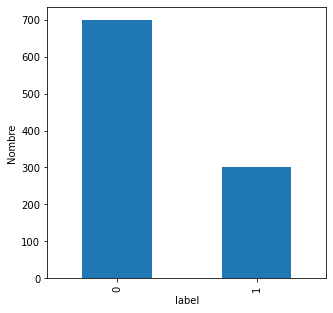

In [5]:
plt.figure(figsize=(5, 5))
# répartition des bons/mauvais payeurs
data['label'].value_counts().plot(kind='bar')
plt.ylabel('Nombre')
plt.xlabel('label')
plt.show()

In [6]:
#résumé statistique pour les variables quantitatives
data.describe()

,duration,credit_amount,installment_rate,residence_since,age,number_existing_credits,people_liable,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


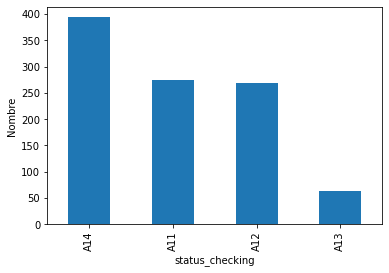

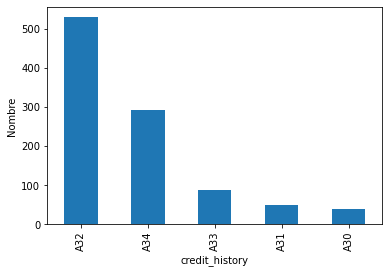

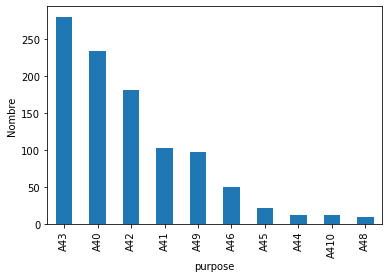

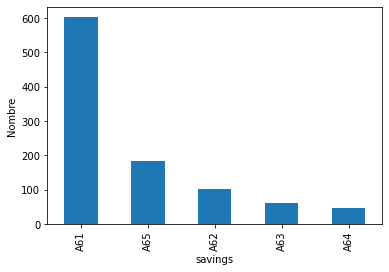

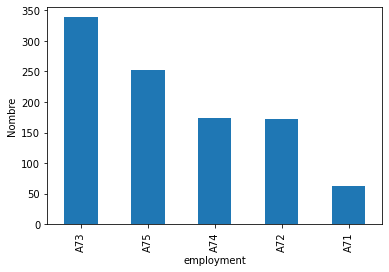

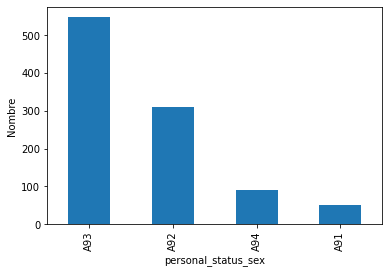

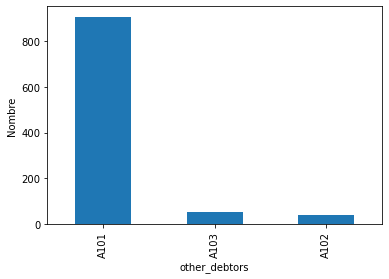

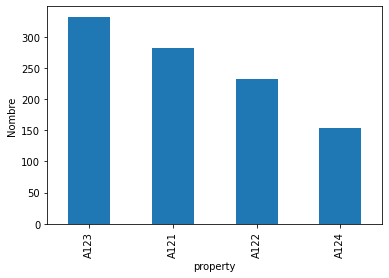

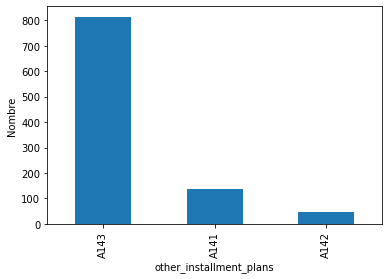

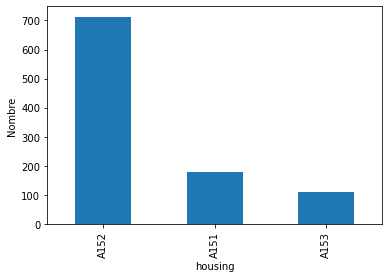

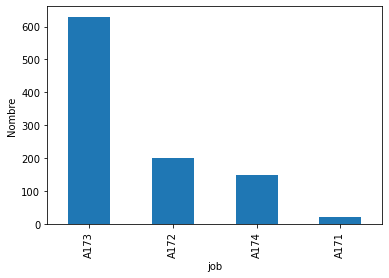

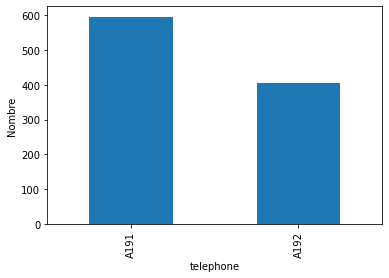

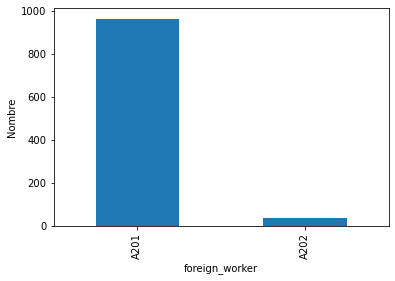

In [7]:
#répartition des modalités pour chaque variable qualitative
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    data[col].value_counts().plot(kind='bar')
    plt.ylabel('Nombre')
    plt.xlabel(col)
    plt.show()

## Analyse bivariée

In [8]:
# Tableau croisé : corrélations avec le label
correlations = {}
for col in num_cols + cat_cols:
    if data[col].dtype == 'object':  # Catégorielle
        corr = data.groupby(col)['label'].mean().var()  # Variance des propas
    else:  # Numérique
        corr = data[[col, 'label']].corr().iloc[0,1]
    correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Corrélation avec risque'])
corr_df['Abs'] = corr_df['Corrélation avec risque'].abs()
corr_df = corr_df.sort_values('Abs', ascending=False)
print(corr_df.head(10))

                         Corrélation avec risque       Abs
duration                                0.214927  0.214927
credit_amount                           0.154739  0.154739
age                                    -0.091127  0.091127
installment_rate                        0.072404  0.072404
number_existing_credits                -0.045732  0.045732
credit_history                          0.036472  0.036472
status_checking                         0.028267  0.028267
foreign_worker                          0.019853  0.019853
other_debtors                           0.015300  0.015300
purpose                                 0.011868  0.011868


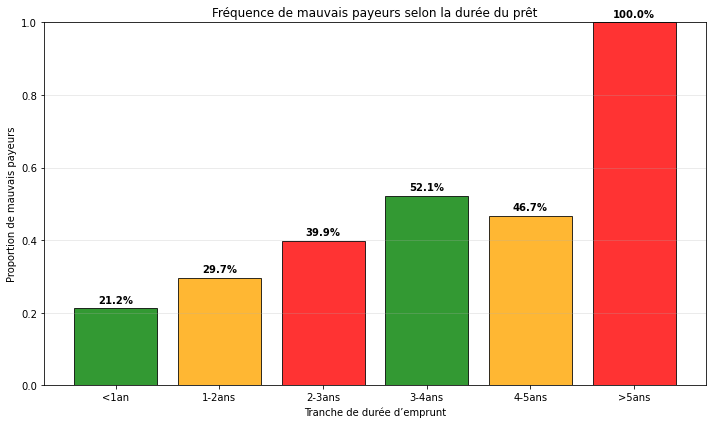

In [9]:
# Création des tranches de durée (en mois)
bins = [0, 12, 24, 36, 48, 60, 100]
labels = ['<1an', '1-2ans', '2-3ans', '3-4ans', '4-5ans', '>5ans']
data['duration_bin'] = pd.cut(data['duration'], bins=bins, labels=labels, right=True)

# Calcul des proportion mauvais payeurs par tranche
duration_risk = (data
                 .groupby('duration_bin')['label']
                 .mean()
                 .reset_index())

# Graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(duration_risk['duration_bin'], duration_risk['label'], 
               color=['green', 'orange', 'red'], alpha=0.8, edgecolor='black')
plt.xlabel('Tranche de durée d’emprunt')
plt.ylabel('Proportion de mauvais payeurs')
plt.title('Fréquence de mauvais payeurs selon la durée du prêt')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Valeurs sur les barres
for bar, prop in zip(bars, duration_risk['label']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{prop:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

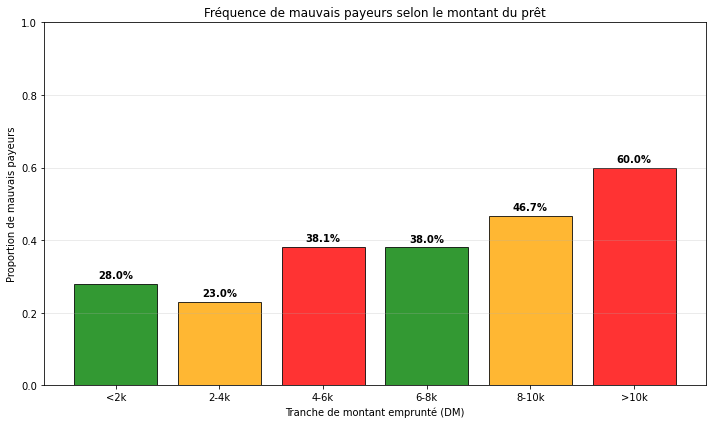

In [10]:
# Création de tranches de montant (DM)
bins = [0, 2000, 4000, 6000, 8000, 10000, data['credit_amount'].max()]
labels = ['<2k', '2-4k', '4-6k', '6-8k', '8-10k', '>10k']
data['amount_bin'] = pd.cut(data['credit_amount'], bins=bins, labels=labels, right=True)

# Calcul des proportions mauvais payeurs
amount_risk = (data
               .groupby('amount_bin')['label']
               .mean()
               .reset_index())

# Graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(amount_risk['amount_bin'], amount_risk['label'], 
               color=['green', 'orange', 'red'], alpha=0.8, edgecolor='black')
plt.xlabel('Tranche de montant emprunté (DM)')
plt.ylabel('Proportion de mauvais payeurs')
plt.title('Fréquence de mauvais payeurs selon le montant du prêt')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Valeurs sur les barres (%)
for bar, prop in zip(bars, amount_risk['label']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{prop:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


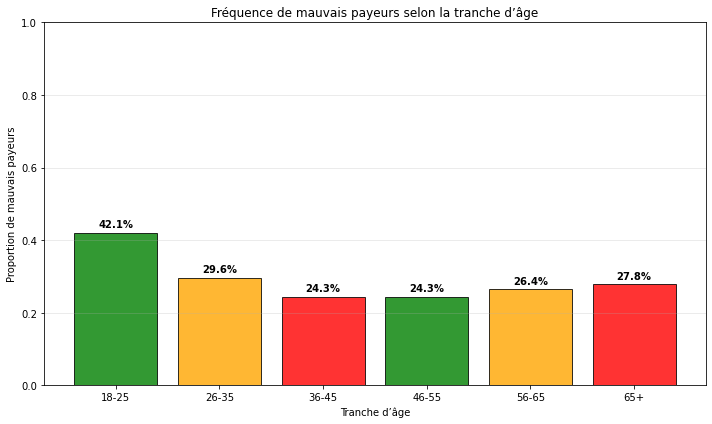

In [11]:
# Création des tranches d'âge
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
data['age_bin'] = pd.cut(data['age'], bins=bins, labels=labels, right=True)

# Calcul de la fréquence de mauvais payeurs (label=1) par tranche
age_risk = (data
            .groupby('age_bin')['label']
            .mean()  # moyenne de 0/1 = proportion de 1
            .reset_index())

# Graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(age_risk['age_bin'], age_risk['label'], 
               color=['green', 'orange', 'red'], alpha=0.8, edgecolor='black')
plt.xlabel('Tranche d’âge')
plt.ylabel('Proportion de mauvais payeurs')
plt.title('Fréquence de mauvais payeurs selon la tranche d’âge')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Valeurs sur les barres (%)
for bar, prop in zip(bars, age_risk['label']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{prop:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

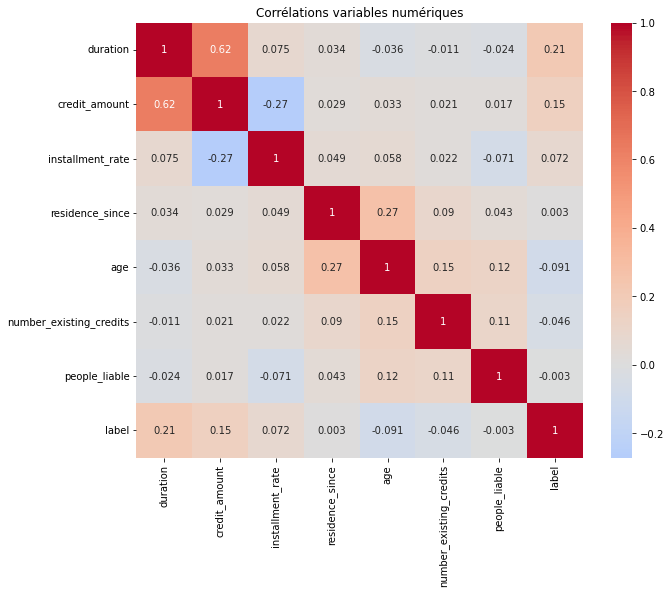

In [12]:
# Matrice des corrélations entre variables numériques
plt.figure(figsize=(10,8))
sns.heatmap(data[num_cols+['label']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations variables numériques')
plt.show()

## Pipeline preprocessing 


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [14]:
# Pipeline preprocessing adapté
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)])

# Split sur les données brutes
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['duration', 'credit_amount',
                                  'installment_rate', 'residence_since', 'age',
                                  'number_existing_credits', 'people_liable']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['status_checking', 'credit_history',
                                  'purpose', 'savings', 'employment',
                                  'personal_status_sex', 'other_debtors',
                                  'property', 'other_installment_plans',
                                  'housing', 'job', 'telephone',
                                  'foreign_worker'])])

## II.A. AFD

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [16]:
# Pipeline pour l'AFD
lda_pipeline = Pipeline([ ('preproc', preprocessor),('lda', LinearDiscriminantAnalysis())])
lda_pipeline

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'credit_amount',
                                                   'installment_rate',
                                                   'residence_since', 'age',
                                                   'number_existing_credits',
                                                   'people_liable']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['status_checking',
                                                   'credit_history', 'purpose',
                                                   'savings', 'employment',
                                                   'personal_status_sex',
                                                   'other_debtors', 'property',
                                                   'other_installment_plans',
                                                   'housing', 'job',
                                                   'telephone',
                                                   'foreign_worker'])])),
                ('lda', LinearDiscriminantAnalysis())])

### Entraînement et prédiction

In [17]:
# Entraînement
lda_pipeline.fit(X_train, y_train)

# Prédictions
y_pred_train = lda_pipeline.predict(X_train)
y_pred_test = lda_pipeline.predict(X_test)
y_proba_test = lda_pipeline.predict_proba(X_test)[:,1]

# Résultats
print("=== Analyse Factorielle Discriminante ===")
print(f"Accuracy Train: {lda_pipeline.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {lda_pipeline.score(X_test, y_test):.3f}")

=== Analyse Factorielle Discriminante ===
Accuracy Train: 0.790
Accuracy Test:  0.757


In [18]:
# Scores
from sklearn.metrics import classification_report
print("\t========= Métriques pour l'AFD ============")
print(classification_report(y_test, y_pred_test))

	========= Métriques pour l'AFD ============
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       210
           1       0.61      0.51      0.56        90

    accuracy                           0.76       300
   macro avg       0.71      0.69      0.69       300
weighted avg       0.75      0.76      0.75       300



In [19]:
#Score AUC
y_pred_test = lda_pipeline.predict(X_test)
y_proba_test = lda_pipeline.predict_proba(X_test)[:,1]
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test):.3f}")

AUC Test: 0.798


### Matrice de coûts

In [20]:
from sklearn.metrics import confusion_matrix

#Matrice de confusion sur le jeu test et calcul du coût
cm = confusion_matrix(y_test, y_pred_test)
cost = 5 * cm[1,0] + 1 * cm[0,1]  # 5*FN + 1*FP
print(f"\nMatrice de confusion:\n{cm}")
print(f"Coût total (5*FN + FP): {cost}")


Matrice de confusion:
[[181  29]
 [ 44  46]]
Coût total (5*FN + FP): 249


## II.B. Arbre de décision

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Pipeline pour l'arbre de décision
cart_pipeline = Pipeline([ 
    ('preproc', preprocessor), 
    ('cart', DecisionTreeClassifier(criterion='gini', random_state=42))
])

#Grille de paramètres à tester
param_grid = {
    'cart__max_depth': [3, 5, 7, 10, None],        # None = arbre complet
    'cart__min_samples_leaf': [1, 5, 10, 20],      # seuil feuilles
}

#GridSearch 5-fold (stratifié par défaut)
grid_search = GridSearchCV(
    cart_pipeline, param_grid, 
    cv=5,  # 5-fold CV
    scoring='roc_auc',  # optimiser AUC (meilleur que accuracy)
    n_jobs=-1,  # parallel
    verbose=1
)
grid_search.fit(X_train, y_train)
# Meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV :", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs paramètres : {'cart__max_depth': 5, 'cart__min_samples_leaf': 20}
Meilleur score CV : 0.7239067055393585


In [22]:
# Pipeline optimisé (meilleurs params)
cart_opti = grid_search.best_estimator_

# Prédictions
y_pred_train = cart_opti.predict(X_train)
y_pred_test  = cart_opti.predict(X_test)
y_proba_test = cart_opti.predict_proba(X_test)[:, 1]

# Résultats accuracy
print("\n=== Arbre CART OPTIMAL ===")
print(f"Accuracy Train: {cart_opti.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {cart_opti.score(X_test, y_test):.3f}")
# Rapport de classification
print("\n\t========= Métriques CART optimal ============")
print(classification_report(y_test, y_pred_test))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test):.3f}")


=== Arbre CART OPTIMAL ===
Accuracy Train: 0.760
Accuracy Test:  0.703

	========= Métriques CART optimal ============
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       210
           1       0.51      0.48      0.49        90

    accuracy                           0.70       300
   macro avg       0.64      0.64      0.64       300
weighted avg       0.70      0.70      0.70       300

AUC Test: 0.708


In [23]:
# Matrice de coûts
cm = confusion_matrix(y_test, y_pred_test)
cost = 5 * cm[1, 0] + cm[0, 1]
print(f"\nMatrice de confusion:\n{cm}")
print(f"Coût total (5*FN + FP): {cost}")


Matrice de confusion:
[[168  42]
 [ 47  43]]
Coût total (5*FN + FP): 277


In [24]:
# code avec l'ajout de la pénalité sur la classe minoritaire 
# Pipeline pour l'arbre de décision
cart_pipeline2 = Pipeline([ 
    ('preproc', preprocessor), 
    ('cart', DecisionTreeClassifier(criterion='gini', random_state=42,class_weight = 'balanced'))
])
#GridSearch 5-fold (stratifié par défaut)
grid_search2 = GridSearchCV(
    cart_pipeline2, param_grid, 
    cv=5,  # 5-fold CV
    scoring='roc_auc',  # optimiser AUC (meilleur que accuracy)
    n_jobs=-1,  # parallel
    verbose=1
)
grid_search2.fit(X_train, y_train)
# Meilleurs paramètres
print("Meilleurs paramètres :", grid_search2.best_params_)
print("Meilleur score CV :", grid_search2.best_score_)
# Pipeline optimisé (meilleurs params)
cart_opti2 = grid_search2.best_estimator_
# Prédictions
y_pred_train2 = cart_opti2.predict(X_train)
y_pred_test2  = cart_opti2.predict(X_test)
y_proba_test2 = cart_opti2.predict_proba(X_test)[:, 1]
# Résultats accuracy
print("\n=== Arbre CART OPTIMAL ===")
print(f"Accuracy Train: {cart_opti2.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {cart_opti2.score(X_test, y_test):.3f}")
# Rapport de classification
print("\n\t========= Métriques CART optimal ============")
print(classification_report(y_test, y_pred_test2))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test2):.3f}")
# Matrice de coûts
cm2 = confusion_matrix(y_test, y_pred_test2)
cost2 = 5 * cm2[1, 0] + cm2[0, 1]
print(f"\nMatrice de confusion:\n{cm2}")
print(f"Coût total (5*FN + FP): {cost2}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs paramètres : {'cart__max_depth': 3, 'cart__min_samples_leaf': 20}
Meilleur score CV : 0.7185374149659863

=== Arbre CART OPTIMAL ===
Accuracy Train: 0.673
Accuracy Test:  0.637

	========= Métriques CART optimal ============
              precision    recall  f1-score   support

           0       0.84      0.59      0.69       210
           1       0.44      0.74      0.55        90

    accuracy                           0.64       300
   macro avg       0.64      0.67      0.62       300
weighted avg       0.72      0.64      0.65       300

AUC Test: 0.712

Matrice de confusion:
[[124  86]
 [ 23  67]]
Coût total (5*FN + FP): 201


## II.C. Forêt aléatoire

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Pipeline Forêt Aléatoire
rf_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('rf', RandomForestClassifier(random_state=42, criterion='gini',class_weight = 'balanced'))
])

# Grille optimisée 
param_grid_rf = {
    'rf__n_estimators': [20,50,100],      # nb arbres
    'rf__max_depth': [5, 10, 20],      # profondeur
    'rf__min_samples_leaf': [1, 5, 10],  # seuil feuilles
}

# GridSearchCV

grid_rf = GridSearchCV(
    rf_pipeline, param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit
grid_rf.fit(X_train, y_train)
print("Meilleurs hyperparamètres:", grid_rf.best_params_)
print(f"Score CV AUC: {grid_rf.best_score_:.3f}")

# Modèle optimal
rf_opti = grid_rf.best_estimator_

# Prédictions
y_pred_train_rf = rf_opti.predict(X_train)
y_pred_test_rf  = rf_opti.predict(X_test)
y_proba_test_rf = rf_opti.predict_proba(X_test)[:, 1]

# Résultats
print("\n=== Forêt Aléatoire OPTIMALE ===")
print(f"Accuracy Train: {rf_opti.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {rf_opti.score(X_test, y_test):.3f}")

print("\n\t========= Métriques RF ============")
print(classification_report(y_test, y_pred_test_rf))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test_rf):.3f}")

# Coût
cm_rf = confusion_matrix(y_test, y_pred_test_rf)
cost_rf = 5 * cm_rf[1, 0] + cm_rf[0, 1]
print(f"\nMatrice de confusion:\n{cm_rf}")
print(f"Coût total (5*FN + FP): {cost_rf}")



Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres: {'rf__max_depth': 10, 'rf__min_samples_leaf': 10, 'rf__n_estimators': 20}
Score CV AUC: 0.771

=== Forêt Aléatoire OPTIMALE ===
Accuracy Train: 0.783
Accuracy Test:  0.680

	========= Métriques RF ============
              precision    recall  f1-score   support

           0       0.82      0.69      0.75       210
           1       0.48      0.66      0.55        90

    accuracy                           0.68       300
   macro avg       0.65      0.67      0.65       300
weighted avg       0.72      0.68      0.69       300

AUC Test: 0.751

Matrice de confusion:
[[145  65]
 [ 31  59]]
Coût total (5*FN + FP): 220


## II.D. AdaBoost

In [26]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Pipeline AdaBoost 
ada_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('ada', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42,class_weight = 'balanced'),
        random_state=42
    ))
])

param_grid_ada = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.1, 0.5, 1.0],
}

# GridSearch 
grid_ada = GridSearchCV(ada_pipeline, param_grid_ada, cv=5, 
                       scoring='roc_auc', n_jobs=-1, verbose=1)
grid_ada.fit(X_train, y_train)
print("Meilleurs hyperparamètres:", grid_ada.best_params_)
print(f"Score CV AUC:   {grid_ada.best_score_:.3f}")
# Modèle optimal + résultats 
ada_opti = grid_ada.best_estimator_
y_pred_train_ada = ada_opti.predict(X_train)
y_pred_test_ada  = ada_opti.predict(X_test)
y_proba_test_ada = ada_opti.predict_proba(X_test)[:, 1]

print("\n=== AdaBoost OPTIMAL ===")
print(f"Accuracy Train: {ada_opti.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {ada_opti.score(X_test, y_test):.3f}")


print("\n\t========= Métriques AdaBoost ============")
print(classification_report(y_test, y_pred_test_ada))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test_ada):.3f}")

# Coût
cm_ada = confusion_matrix(y_test, y_pred_test_ada)
cost_ada = 5 * cm_ada[1, 0] + cm_ada[0, 1]
print(f"\nMatrice de confusion:\n{cm_ada}")
print(f"Coût total (5*FN + FP): {cost_ada}")


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Meilleurs hyperparamètres: {'ada__learning_rate': 0.1, 'ada__n_estimators': 200}
Score CV AUC:   0.766

=== AdaBoost OPTIMAL ===
Accuracy Train: 0.740
Accuracy Test:  0.713

	========= Métriques AdaBoost ============
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       210
           1       0.52      0.72      0.60        90

    accuracy                           0.71       300
   macro avg       0.69      0.72      0.69       300
weighted avg       0.75      0.71      0.72       300

AUC Test: 0.791

Matrice de confusion:
[[149  61]
 [ 25  65]]
Coût total (5*FN + FP): 186


## II.E. SVM avec RBF

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Pipeline SVM 
svm_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('svm', SVC(probability=True, random_state=42, kernel='rbf',class_weight = 'balanced'))
])

# Grille SVM (C + gamma)
param_grid_svm = {
    'svm__C': [0.1, 1, 10],        # régularisation
    'svm__gamma': ['scale', 'auto', 0.01]  # taille du noyau 
  }

# GridSearch
grid_svm = GridSearchCV(
    svm_pipeline, param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit
grid_svm.fit(X_train, y_train)
print("Meilleurs hyperparamètres:", grid_svm.best_params_)
print(f"Score CV AUC: {grid_svm.best_score_:.3f}")

# Modèle optimal
svm_opti = grid_svm.best_estimator_

# Prédictions
y_pred_train_svm = svm_opti.predict(X_train)
y_pred_test_svm  = svm_opti.predict(X_test)
y_proba_test_svm = svm_opti.predict_proba(X_test)[:, 1]

# Résultats
print("\n=== SVM RBF OPTIMAL ===")
print(f"Accuracy Train: {svm_opti.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {svm_opti.score(X_test, y_test):.3f}")

print("\n\t========= Métriques SVM ============")
print(classification_report(y_test, y_pred_test_svm))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test_svm):.3f}")

# Coût
cm_svm = confusion_matrix(y_test, y_pred_test_svm)
cost_svm = 5 * cm_svm[1, 0] + cm_svm[0, 1]
print(f"\nMatrice de confusion:\n{cm_svm}")
print(f"Coût total (5*FN + FP): {cost_svm}")



Fitting 5 folds for each of 9 candidates, totalling 45 fits
Meilleurs hyperparamètres: {'svm__C': 1, 'svm__gamma': 0.01}
Score CV AUC: 0.763

=== SVM RBF OPTIMAL ===
Accuracy Train: 0.721
Accuracy Test:  0.697

	========= Métriques SVM ============
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       210
           1       0.50      0.80      0.61        90

    accuracy                           0.70       300
   macro avg       0.69      0.73      0.68       300
weighted avg       0.77      0.70      0.71       300

AUC Test: 0.799

Matrice de confusion:
[[137  73]
 [ 18  72]]
Coût total (5*FN + FP): 163


## II.F. MLP

In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Pipeline Perceptron Multicouche
mlp_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000))
])

#  Grille MLP (couches + régularisation)
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,),(100,), (50,50), (100,50)],  # architectures 
    'mlp__alpha': [0.0001,0.001, 0.01],                            # L2 régularisation 
    'mlp__learning_rate_init': [0.001, 0.01],                       # pas d'apprentissage
    'mlp__solver': ['adam', 'sgd']                                  # optimiseur
}

# GridSearch (réduit pour rapidité)
grid_mlp = GridSearchCV(
    mlp_pipeline, param_grid_mlp,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit
grid_mlp.fit(X_train, y_train)
print(" Meilleurs hyperparamètres:", grid_mlp.best_params_)
print(f"Score CV AUC: {grid_mlp.best_score_:.3f}")

# Modèle optimal
mlp_opti = grid_mlp.best_estimator_

# Prédictions
y_pred_train_mlp = mlp_opti.predict(X_train)
y_pred_test_mlp  = mlp_opti.predict(X_test)
y_proba_test_mlp = mlp_opti.predict_proba(X_test)[:, 1]

# Résultats
print("\n=== MLP OPTIMAL ===")
print(f"Accuracy Train: {mlp_opti.score(X_train, y_train):.3f}")
print(f"Accuracy Test:  {mlp_opti.score(X_test, y_test):.3f}")

print("\n\t========= Métriques MLP ============")
print(classification_report(y_test, y_pred_test_mlp))
print(f"AUC Test: {roc_auc_score(y_test, y_proba_test_mlp):.3f}")

# Coût
cm_mlp = confusion_matrix(y_test, y_pred_test_mlp)
cost_mlp = 5 * cm_mlp[1, 0] + cm_mlp[0, 1]
print(f"\nMatrice de confusion:\n{cm_mlp}")
print(f"Coût total (5*FN + FP): {cost_mlp}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/srv/conda/envs/notebook/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/srv/conda/envs/notebook/lib

 Meilleurs hyperparamètres: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'sgd'}
Score CV AUC: 0.751

=== MLP OPTIMAL ===
Accuracy Train: 0.850
Accuracy Test:  0.773

	========= Métriques MLP ============
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       210
           1       0.62      0.61      0.62        90

    accuracy                           0.77       300
   macro avg       0.73      0.73      0.73       300
weighted avg       0.77      0.77      0.77       300

AUC Test: 0.815

Matrice de confusion:
[[177  33]
 [ 35  55]]
Coût total (5*FN + FP): 208


/srv/conda/envs/notebook/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
